# COMP 3610 Assignment 4
## MLOps and Model Deployment

## Imports

This section loads the packages needed for the data work, model training, and MLflow tracking.

In [13]:
import io
import json
from datetime import datetime
from pathlib import Path
from urllib import request

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Data download and processing

Using the same process as the training done for the previous assignment. The model will be retrained.

In [ ]:
def load_data():

    parq_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
    lut_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

    with request.urlopen(parq_url) as parq_file:
        parquet_bytes = parq_file.read()

    df = pd.read_parquet(io.BytesIO(parquet_bytes))

    with request.urlopen(lut_url) as lut_file:
        lut_bytes = lut_file.read()

    lut = pd.read_csv(io.BytesIO(lut_bytes))


    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

    required_columns = [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "PULocationID",
        "DOLocationID",
        "passenger_count",
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "total_amount",
        "payment_type"
    ]

    df = df.dropna(subset=required_columns).copy()

    df = df[(df["trip_distance"] > 0.0) &
            (df["fare_amount"] > 0.0) &
            (df["total_amount"] > 0.0) &
            (df["total_amount"] <= 500)].copy()

    df = df[(df["tpep_pickup_datetime"] < df["tpep_dropoff_datetime"]) &
            (df["tpep_pickup_datetime"] >= datetime(2024, 1, 1)) &
            (df["tpep_pickup_datetime"] < datetime(2024, 2, 1))].copy()

    df = df[df["payment_type"] == 1].copy()

    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
    df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
    df["is_weekend"] = df["pickup_day_of_week"].isin([5, 6]).astype(int)

    df["trip_duration_minutes"] = (
        (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60.0
    )

    df["trip_speed_mph"] = np.where(
        df["trip_duration_minutes"] > 0,
        df["trip_distance"] / (df["trip_duration_minutes"] / 60.0),
        0
    )

    df["log_trip_distance"] = np.log1p(df["trip_distance"])

    df["fare_per_mile"] = np.where(
        df["trip_distance"] > 0,
        df["fare_amount"] / df["trip_distance"],
        0
    )

    df["fare_per_minute"] = np.where(
        df["trip_duration_minutes"] > 0,
        df["fare_amount"] / df["trip_duration_minutes"],
        0
    )

    pickup_lut = lut[["LocationID", "Borough"]].rename(columns={
        "LocationID": "PULocationID",
        "Borough": "pickup_borough"
    })

    dropoff_lut = lut[["LocationID", "Borough"]].rename(columns={
        "LocationID": "DOLocationID",
        "Borough": "dropoff_borough"
    })

    df = df.merge(pickup_lut, on="PULocationID", how="left")
    df = df.merge(dropoff_lut, on="DOLocationID", how="left")

    df["pickup_borough"] = df["pickup_borough"].fillna("Unknown")
    df["dropoff_borough"] = df["dropoff_borough"].fillna("Unknown")

    df["target_tip_amount"] = df["tip_amount"]

    df["high_tip"] = (df["tip_amount"] > 0.20 * df["fare_amount"]).astype(int)

    df = df.reset_index(drop=True)
    return df

df = load_data()
print(df.shape)
df.head()

(2298335, 31)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute,pickup_borough,dropoff_borough,target_tip_amount,high_tip
0,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.8,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,0,0,0,6.600000,16.363636,1.029619,5.555556,1.515152,Manhattan,Manhattan,3.75,1
1,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.7,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0,0,0,0,17.916667,15.739535,1.740466,4.957447,1.300465,Manhattan,Manhattan,3.00,0
2,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.4,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0,0,0,0,8.300000,10.120482,0.875469,7.142857,1.204819,Manhattan,Manhattan,2.00,0
3,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.8,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0,0,0,0,6.100000,7.868852,0.587787,9.875000,1.295082,Manhattan,Manhattan,3.20,1
4,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.7,1.0,N,148,141,1,29.6,3.5,0.5,6.90,0.0,1.0,41.50,2.5,0.0,0,0,0,32.383333,8.708183,1.740466,6.297872,0.914050,Manhattan,Manhattan,6.90,1


## Feature setup

The full processed dataset is split first. After that, a stratified sample of the training set is used only for tuning. The final test set still comes from the full processed data.


In [15]:

FEATURE_COLUMNS = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "trip_duration_minutes",
    "trip_speed_mph",
    "log_trip_distance",
    "fare_per_mile",
    "fare_per_minute",
    "pickup_borough",
    "dropoff_borough",
]

TARGET_COLUMN = "target_tip_amount"
NUMERIC_FEATURES = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "trip_duration_minutes",
    "trip_speed_mph",
    "log_trip_distance",
    "fare_per_mile",
    "fare_per_minute",
]
CATEGORICAL_FEATURES = ["pickup_borough", "dropoff_borough"]

# reduce memory a bit
for col in NUMERIC_FEATURES + [TARGET_COLUMN]:
    if df[col].dtype == "float64":
        df[col] = df[col].astype("float32")
    elif df[col].dtype == "int64":
        df[col] = df[col].astype("int32")

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

# full split for final evaluation
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# stratified sample only for tuning
TUNING_SAMPLE_SIZE = 200000

train_tune_df = X_train_full.copy()
train_tune_df[TARGET_COLUMN] = y_train_full.values
train_tune_df["target_bin"] = pd.qcut(
    train_tune_df[TARGET_COLUMN],
    q=10,
    labels=False,
    duplicates="drop",
)

tune_df, _ = train_test_split(
    train_tune_df,
    train_size=TUNING_SAMPLE_SIZE,
    random_state=42,
    stratify=train_tune_df["target_bin"],
)

tune_df = tune_df.drop(columns=["target_bin"]).reset_index(drop=True)

X_tune = tune_df[FEATURE_COLUMNS].copy()
y_tune = tune_df[TARGET_COLUMN].copy()

print("Full training shape:", X_train_full.shape)
print("Test shape:", X_test.shape)
print("Tuning sample size:", len(tune_df))


Full training shape: (1838668, 13)
Test shape: (459667, 13)
Tuning sample size: 200000


## Preprocessing

In [16]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## MLflow setup

The local MLflow tracking setup.

In [17]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("taxi-tip-prediction")
client = MlflowClient()
print(mlflow.get_tracking_uri())

2026/04/19 03:36:06 INFO mlflow.tracking.fluent: Experiment with name 'taxi-tip-prediction' does not exist. Creating a new experiment.


http://127.0.0.1:5000


## Helper function for metrics

This function is used to keep the model evaluation part short and consistent.

In [18]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

## Model 1: Linear Regression

The first model is Linear Regression.  
A small parameter search is used on the tuning sample. After that, the best version is fit again on the full training set and tested on the full test set.


In [ ]:

linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

linear_param_distributions = {
    "model__fit_intercept": [True, False],
    "model__positive": [False, True],
}

linear_search = RandomizedSearchCV(
    estimator=linear_pipeline,
    param_distributions=linear_param_distributions,
    n_iter=4,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=1,
    verbose=1,
)

with mlflow.start_run(run_name="linear_regression") as run:
    # linear_search.fit(X_tune, y_tune)
    # best_linear_model = linear_search.best_estimator_
    # best_linear_model.fit(X_train_full, y_train_full)

    linear_search = joblib.load('linear_search.joblib')
    best_linear_model = joblib.load('linear_search_best_estimator.joblib')
    
    joblib.dump(linear_search, 'linear_search.joblib')
    joblib.dump(best_linear_model, 'linear_search_best_estimator.joblib')

    linear_pred = best_linear_model.predict(X_test)
    linear_metrics = regression_metrics(y_test, linear_pred)

    mlflow.log_param("model_name", "Linear Regression")
    mlflow.log_param("tuning_sample_size", TUNING_SAMPLE_SIZE)
    mlflow.log_params(linear_search.best_params_)
    mlflow.log_metric("MAE", linear_metrics["MAE"])
    mlflow.log_metric("RMSE", linear_metrics["RMSE"])
    mlflow.log_metric("R2", linear_metrics["R2"])
    mlflow.set_tag("model_type", "linear_regression")
    mlflow.set_tag("dataset_version", "yellow_tripdata_2024-01")

    signature = infer_signature(X_train_full.head(5), best_linear_model.predict(X_train_full.head(5)))
    mlflow.sklearn.log_model(best_linear_model, name="model", signature=signature)

    

    linear_run_id = run.info.run_id



linear_metrics


c:\Users\itach\Desktop\assignment4\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run linear_regression at: http://127.0.0.1:5000/#/experiments/1/runs/2f7a2aaf1a0a49049732bd8d934c4905
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


{'MAE': 1.281707868249787,
 'RMSE': np.float64(2.5002979290144207),
 'R2': 0.5820503151141819}

## Model 2: Random Forest Regressor with tuning

The second model is a Random Forest Regressor.  
The tuning is done on the 200000-row stratified training sample so it can run locally. The best setup is then fit again on the full training set and tested on the full test set.


In [20]:

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=1)),
])

rf_param_distributions = {
    "model__n_estimators": [100],
    "model__max_depth": [20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=1,
    verbose=1,
)

with mlflow.start_run(run_name="random_forest_regressor") as run:
#    rf_search.fit(X_tune, y_tune)
#    best_rf_model = rf_search.best_estimator_
#    best_rf_model.fit(X_train_full, y_train_full)

    rf_search = joblib.load('rf_search.joblib')
    best_rf_model = joblib.load('rf_search_best_estimator.joblib')

    joblib.dump(rf_search, 'rf_search.joblib')
    joblib.dump(best_rf_model, 'rf_search_best_estimator.joblib')

    rf_pred = best_rf_model.predict(X_test)
    rf_metrics = regression_metrics(y_test, rf_pred)

    mlflow.log_param("model_name", "Random Forest Regressor")
    mlflow.log_param("tuning_sample_size", TUNING_SAMPLE_SIZE)
    mlflow.log_params(rf_search.best_params_)
    mlflow.log_metric("MAE", rf_metrics["MAE"])
    mlflow.log_metric("RMSE", rf_metrics["RMSE"])
    mlflow.log_metric("R2", rf_metrics["R2"])
    mlflow.set_tag("model_type", "random_forest_regressor")
    mlflow.set_tag("dataset_version", "yellow_tripdata_2024-01")

    signature = infer_signature(X_train_full.head(5), best_rf_model.predict(X_train_full.head(5)))
    mlflow.sklearn.log_model(best_rf_model, name="model", signature=signature)

    rf_run_id = run.info.run_id

rf_metrics


c:\Users\itach\Desktop\assignment4\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run random_forest_regressor at: http://127.0.0.1:5000/#/experiments/1/runs/bba5284f9d98463c84ee85aadeaccfd8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


{'MAE': 1.2011017578734096,
 'RMSE': np.float64(2.3777467127355467),
 'R2': 0.6220175291348755}

## Run comparison

The table below compares the two regression models on the full test set.  
Both models were tuned on a 200000-row stratified sample from the training data, then fit again on the full training set before final testing.


In [21]:
results_df = pd.DataFrame([
    {"model_name": "Linear Regression", **linear_metrics},
    {"model_name": "Random Forest Regressor", **rf_metrics},
])
results_df

,model_name,MAE,RMSE,R2
0,Linear Regression,1.281708,2.500298,0.582050
1,Random Forest Regressor,1.201102,2.377747,0.622018


The model with the lower RMSE was kept as the better one. RMSE was used first because it matches the tuning score and gives a direct way to compare the final regression runs. The second model was still useful because it showed whether a more flexible model could beat the simpler baseline.


## Register the best model

Registering the best run in the local MLflow Model Registry.

In [23]:
best_model_name = "Linear Regression" if linear_metrics["RMSE"] <= rf_metrics["RMSE"] else "Random Forest Regressor"
best_run_id = linear_run_id if best_model_name == "Linear Regression" else rf_run_id
model_uri = f"runs:/{best_run_id}/model"

registered_model = mlflow.register_model(model_uri=model_uri, name="taxi-tip-regressor")
version_text = (
    f"{best_model_name} selected. "
    f"Linear RMSE={linear_metrics['RMSE']:.4f}. "
    f"RF RMSE={rf_metrics['RMSE']:.4f}."
)
client.update_model_version(
    name="taxi-tip-regressor",
    version=registered_model.version,
    description=version_text,
)

registered_model.version

Successfully registered model 'taxi-tip-regressor'.
2026/04/19 03:39:21 WARNING mlflow.tracking._model_registry.fluent: Run with id bba5284f9d98463c84ee85aadeaccfd8 has no artifacts at artifact path 'model', registering model based on models:/m-72f0df0146694123baf22f6581aac580 instead
2026/04/19 03:39:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 1
Created version '1' of model 'taxi-tip-regressor'.


'1'

## Odd error when updating version. Testing to see if it was still updated correctly

In [24]:
mv = client.get_model_version(
    name="taxi-tip-regressor",
    version=registered_model.version,
)

print(mv.description)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Registry URI:", mlflow.get_registry_uri())

Random Forest Regressor selected. Linear RMSE=2.5003. RF RMSE=2.3777.
Tracking URI: http://127.0.0.1:5000
Registry URI: http://127.0.0.1:5000


## Load the model from the registry and make a sample prediction

This shows that the registered model can be loaded and used again.

In [25]:
registry_uri = f"models:/taxi-tip-regressor/{registered_model.version}"
loaded_model = mlflow.pyfunc.load_model(registry_uri)
sample_input = X_test.head(1)
sample_prediction = loaded_model.predict(sample_input)
print(sample_input)
print("Predicted tip amount:", sample_prediction[0])

        passenger_count  trip_distance  fare_amount  pickup_hour  pickup_day_of_week  is_weekend  trip_duration_minutes  trip_speed_mph  log_trip_distance  fare_per_mile  fare_per_minute  \
992482              6.0           1.93         12.1           10                   0           0                   11.0       10.527273           1.075002        6.26943              1.1   

       pickup_borough dropoff_borough  
992482      Manhattan       Manhattan  
Predicted tip amount: 2.9060154247371197


## Save the model files for the API

The API file loads a saved model from the `models` folder.  
This cell writes the best model and a small metadata file for the endpoints.


In [27]:
Path("models").mkdir(exist_ok=True)

if best_model_name == "Linear Regression":
    best_model = best_linear_model
    best_metrics = linear_metrics
else:
    best_model = best_rf_model
    best_metrics = rf_metrics

joblib.dump(best_model, "models/taxi_tip_model.pkl")

model_metadata = {
    "model_name": "taxi-tip-regressor",
    "model_version": f"local-{registered_model.version}",
    "best_model": best_model_name,
    "feature_names": FEATURE_COLUMNS,
    "training_metrics": {
        "MAE": float(best_metrics["MAE"]),
        "RMSE": float(best_metrics["RMSE"]),
        "R2": float(best_metrics["R2"]),
    },
    "comparison": [
        {
            "model_name": "Linear Regression",
            "MAE": float(linear_metrics["MAE"]),
            "RMSE": float(linear_metrics["RMSE"]),
            "R2": float(linear_metrics["R2"]),
        },
        {
            "model_name": "Random Forest Regressor",
            "MAE": float(rf_metrics["MAE"]),
            "RMSE": float(rf_metrics["RMSE"]),
            "R2": float(rf_metrics["R2"]),
        },
    ],
}

with open("models/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=2)

model_metadata

{'model_name': 'taxi-tip-regressor',
 'model_version': 'local-1',
 'best_model': 'Random Forest Regressor',
 'feature_names': ['passenger_count',
  'trip_distance',
  'fare_amount',
  'pickup_hour',
  'pickup_day_of_week',
  'is_weekend',
  'trip_duration_minutes',
  'trip_speed_mph',
  'log_trip_distance',
  'fare_per_mile',
  'fare_per_minute',
  'pickup_borough',
  'dropoff_borough'],
 'training_metrics': {'MAE': 1.2011017578734096,
  'RMSE': 2.3777467127355467,
  'R2': 0.6220175291348755},
 'comparison': [{'model_name': 'Linear Regression',
   'MAE': 1.281707868249787,
   'RMSE': 2.5002979290144207,
   'R2': 0.5820503151141819},
  {'model_name': 'Random Forest Regressor',
   'MAE': 1.2011017578734096,
   'RMSE': 2.3777467127355467,
   'R2': 0.6220175291348755}]}

## Screenshots

### MLflow tracking server set up and experiment created

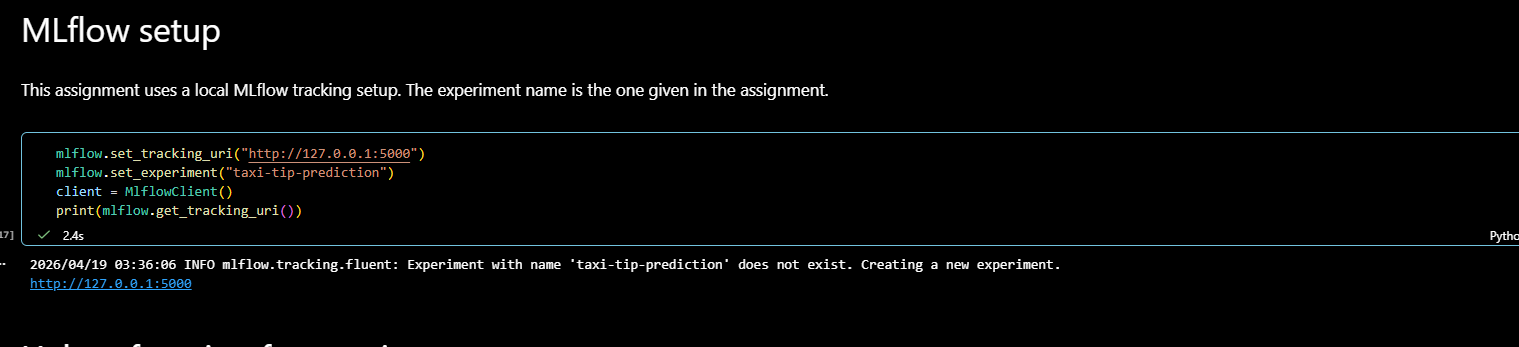

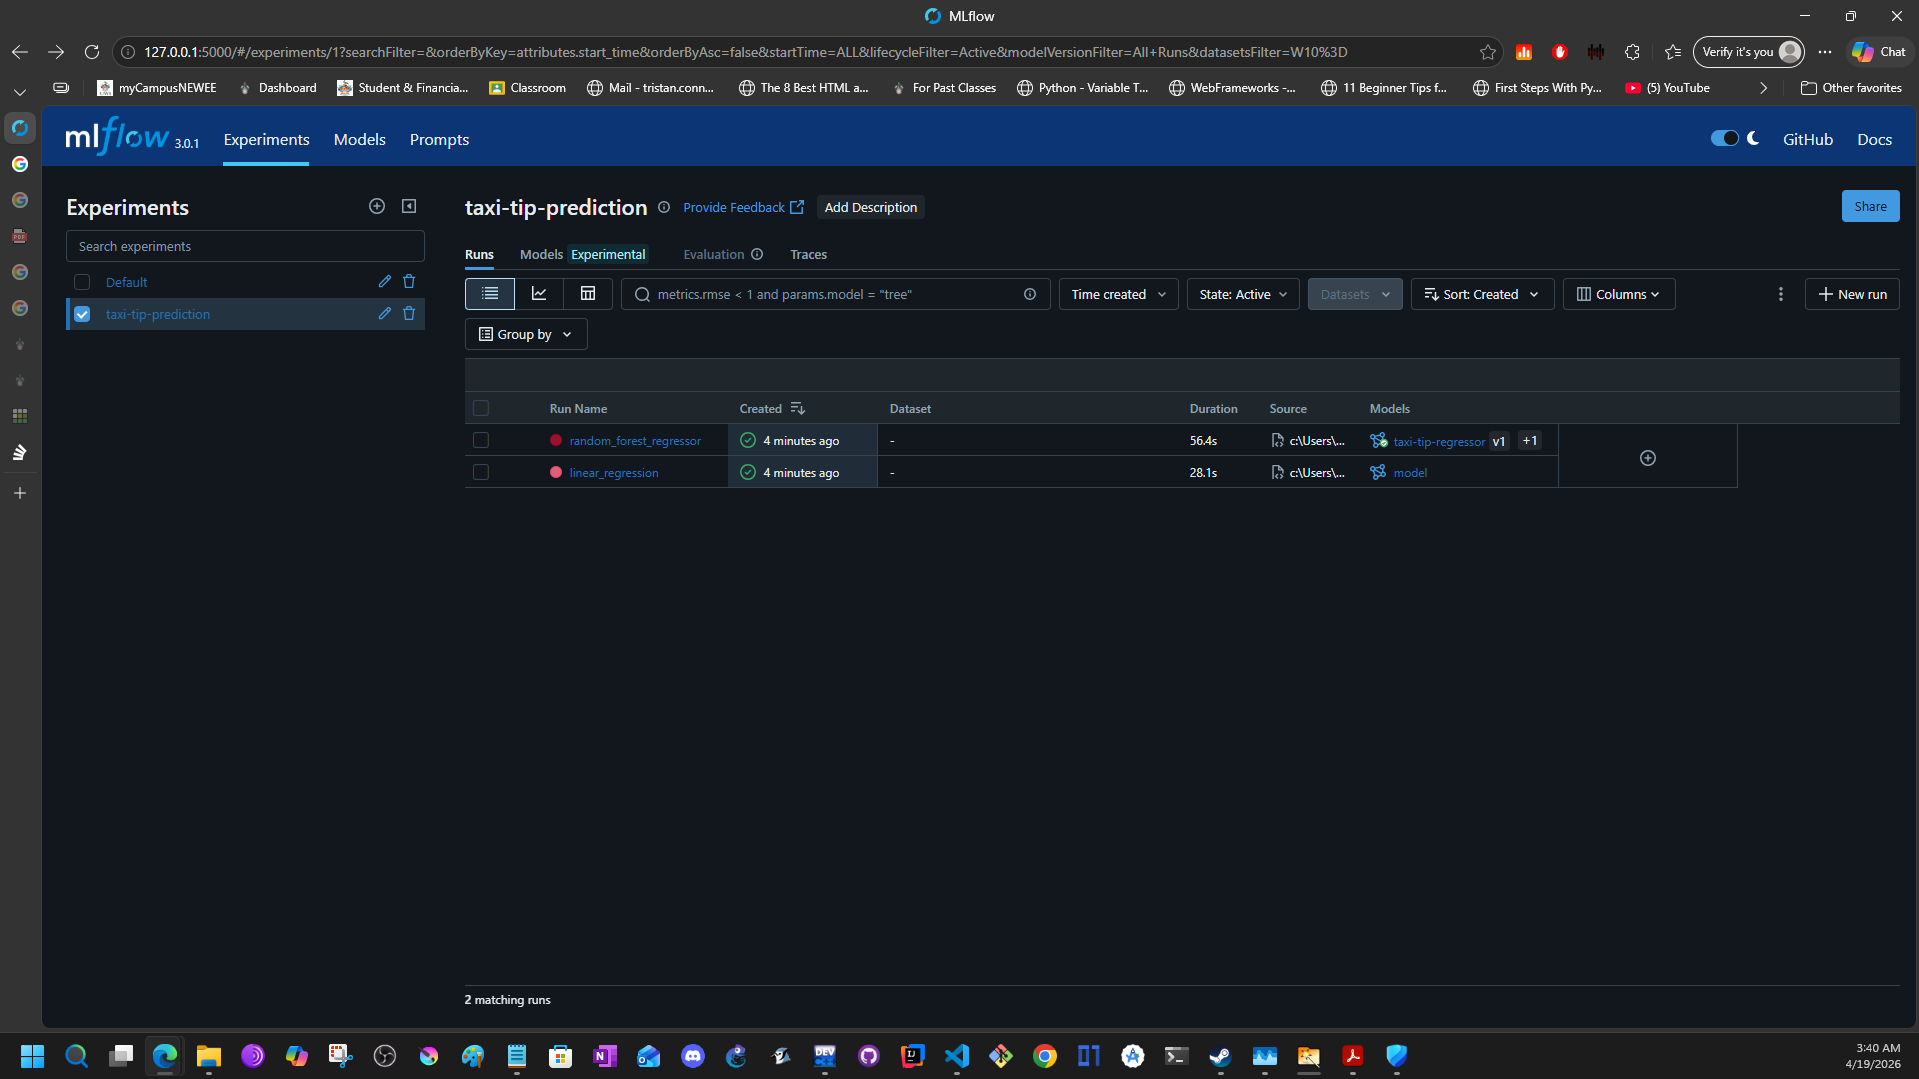


### At least 2 models logged with parameters, metrics, tags and artifacts including MLFlow UI

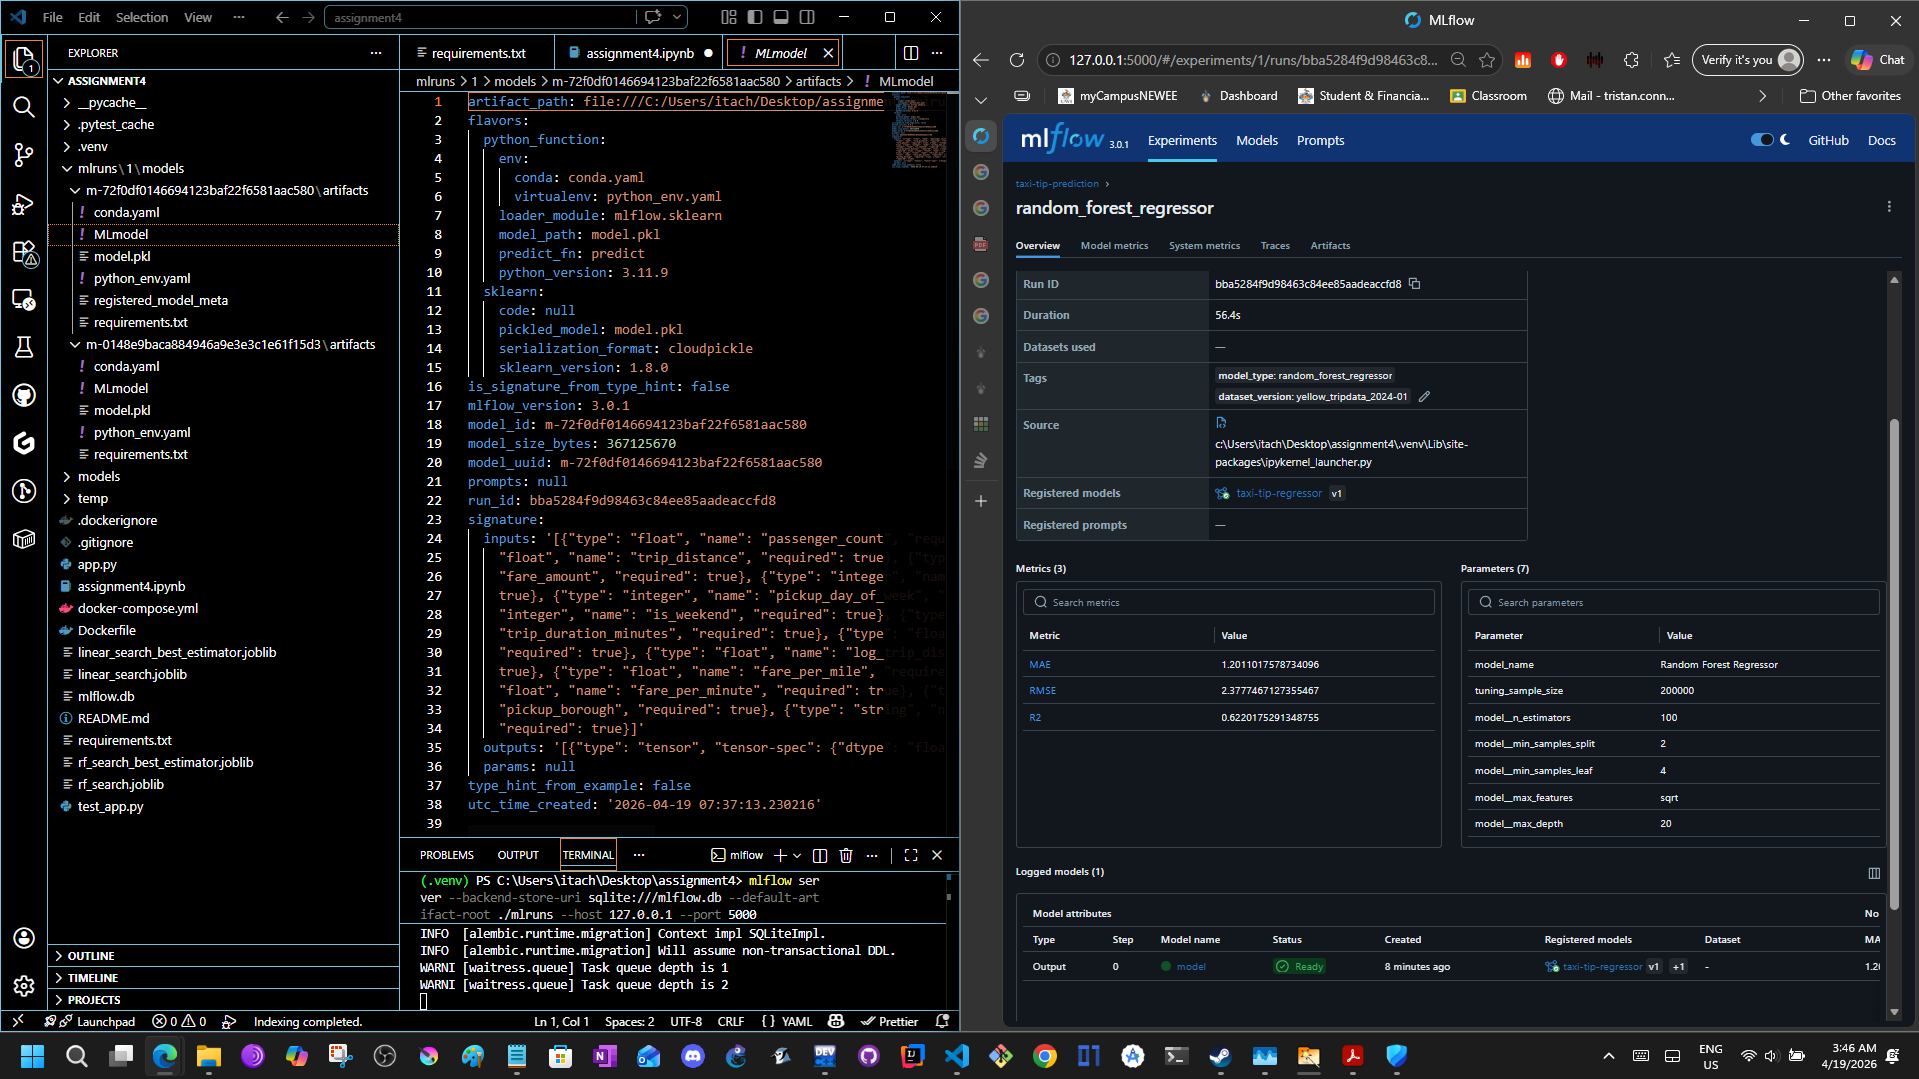

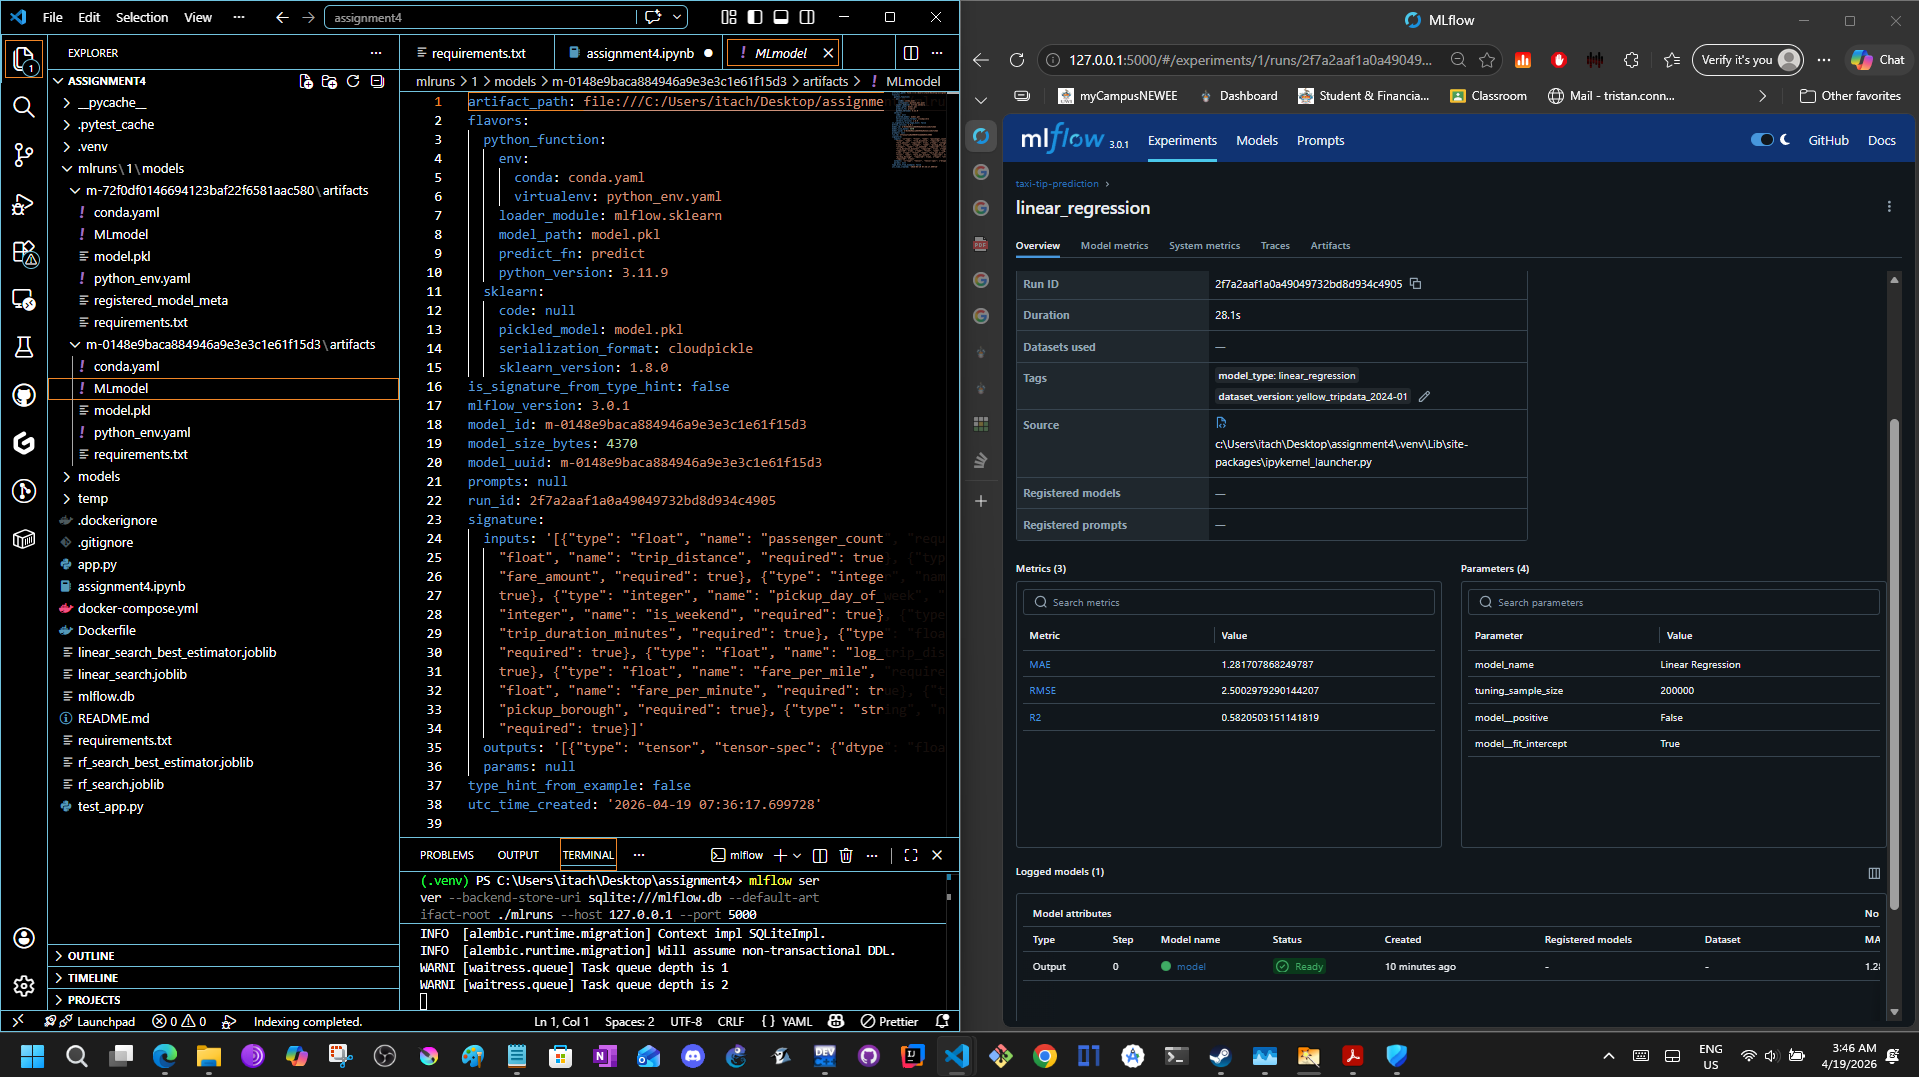

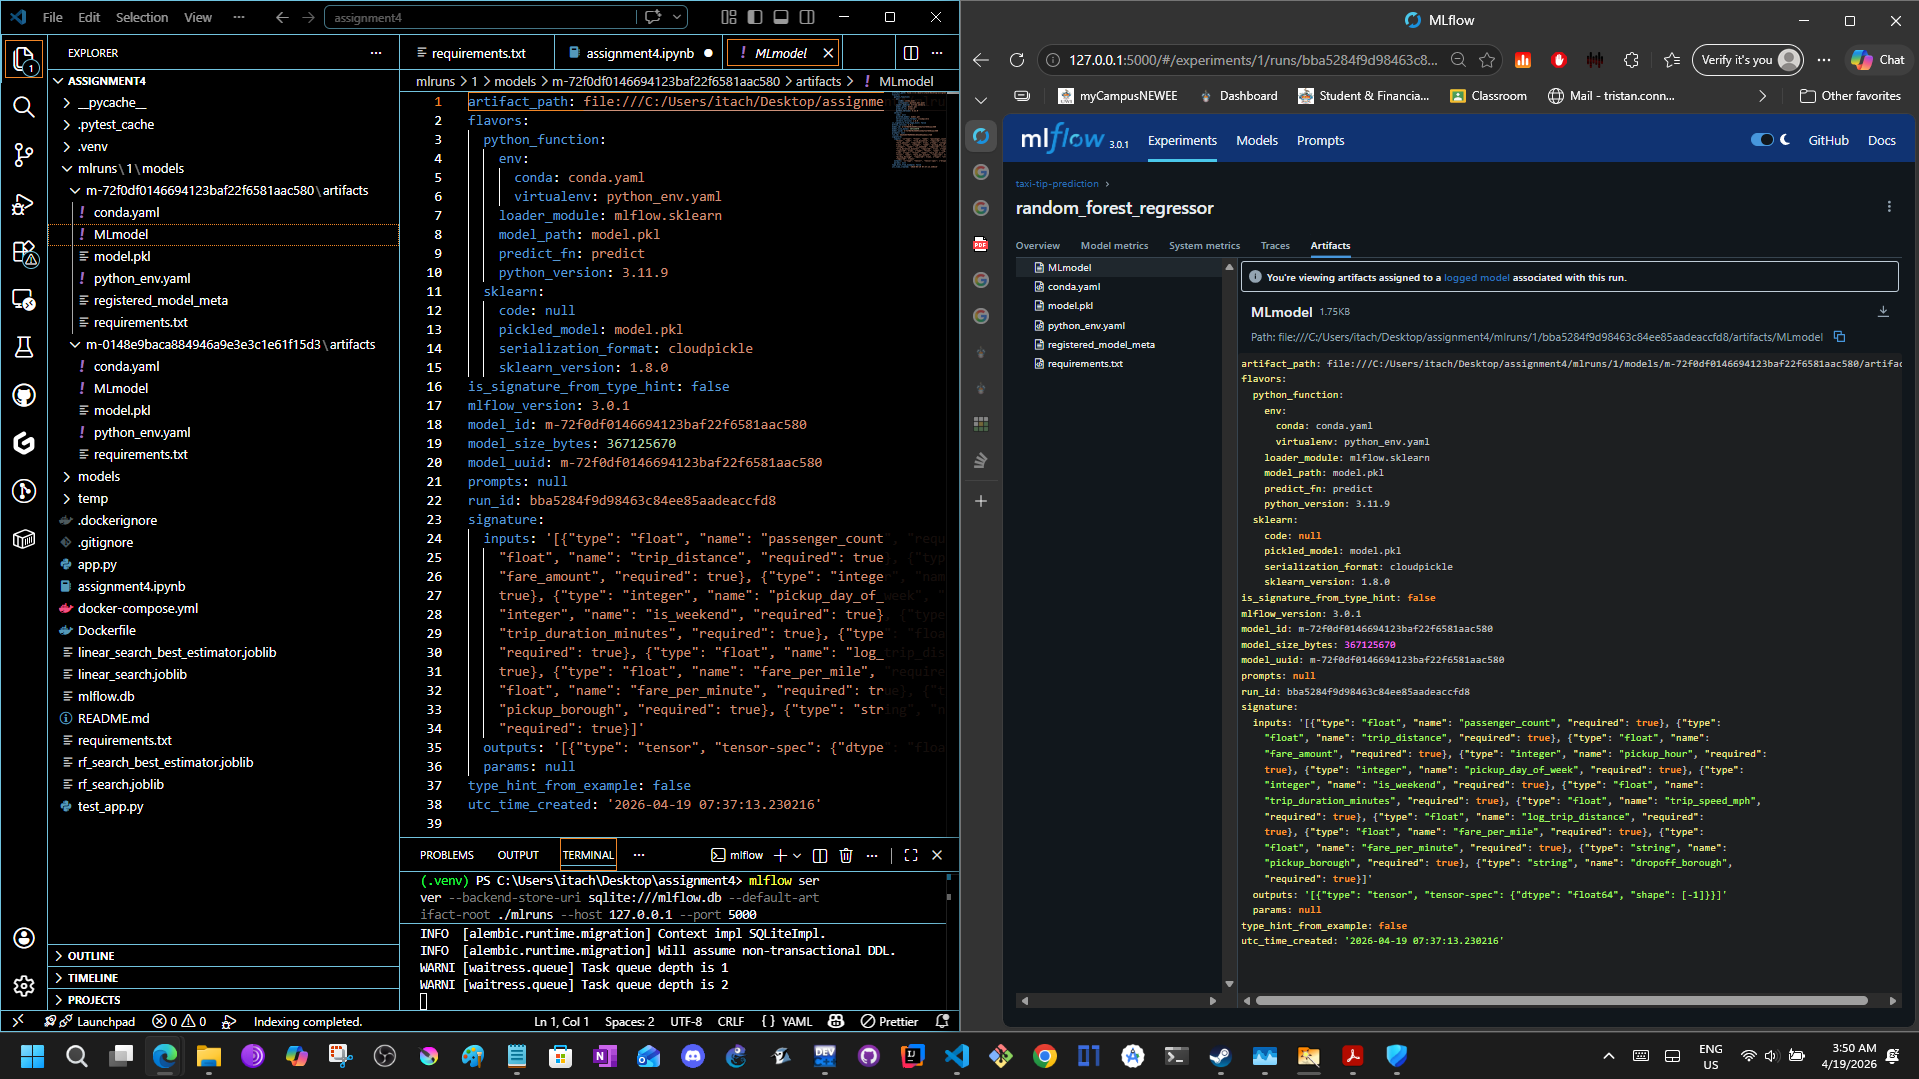

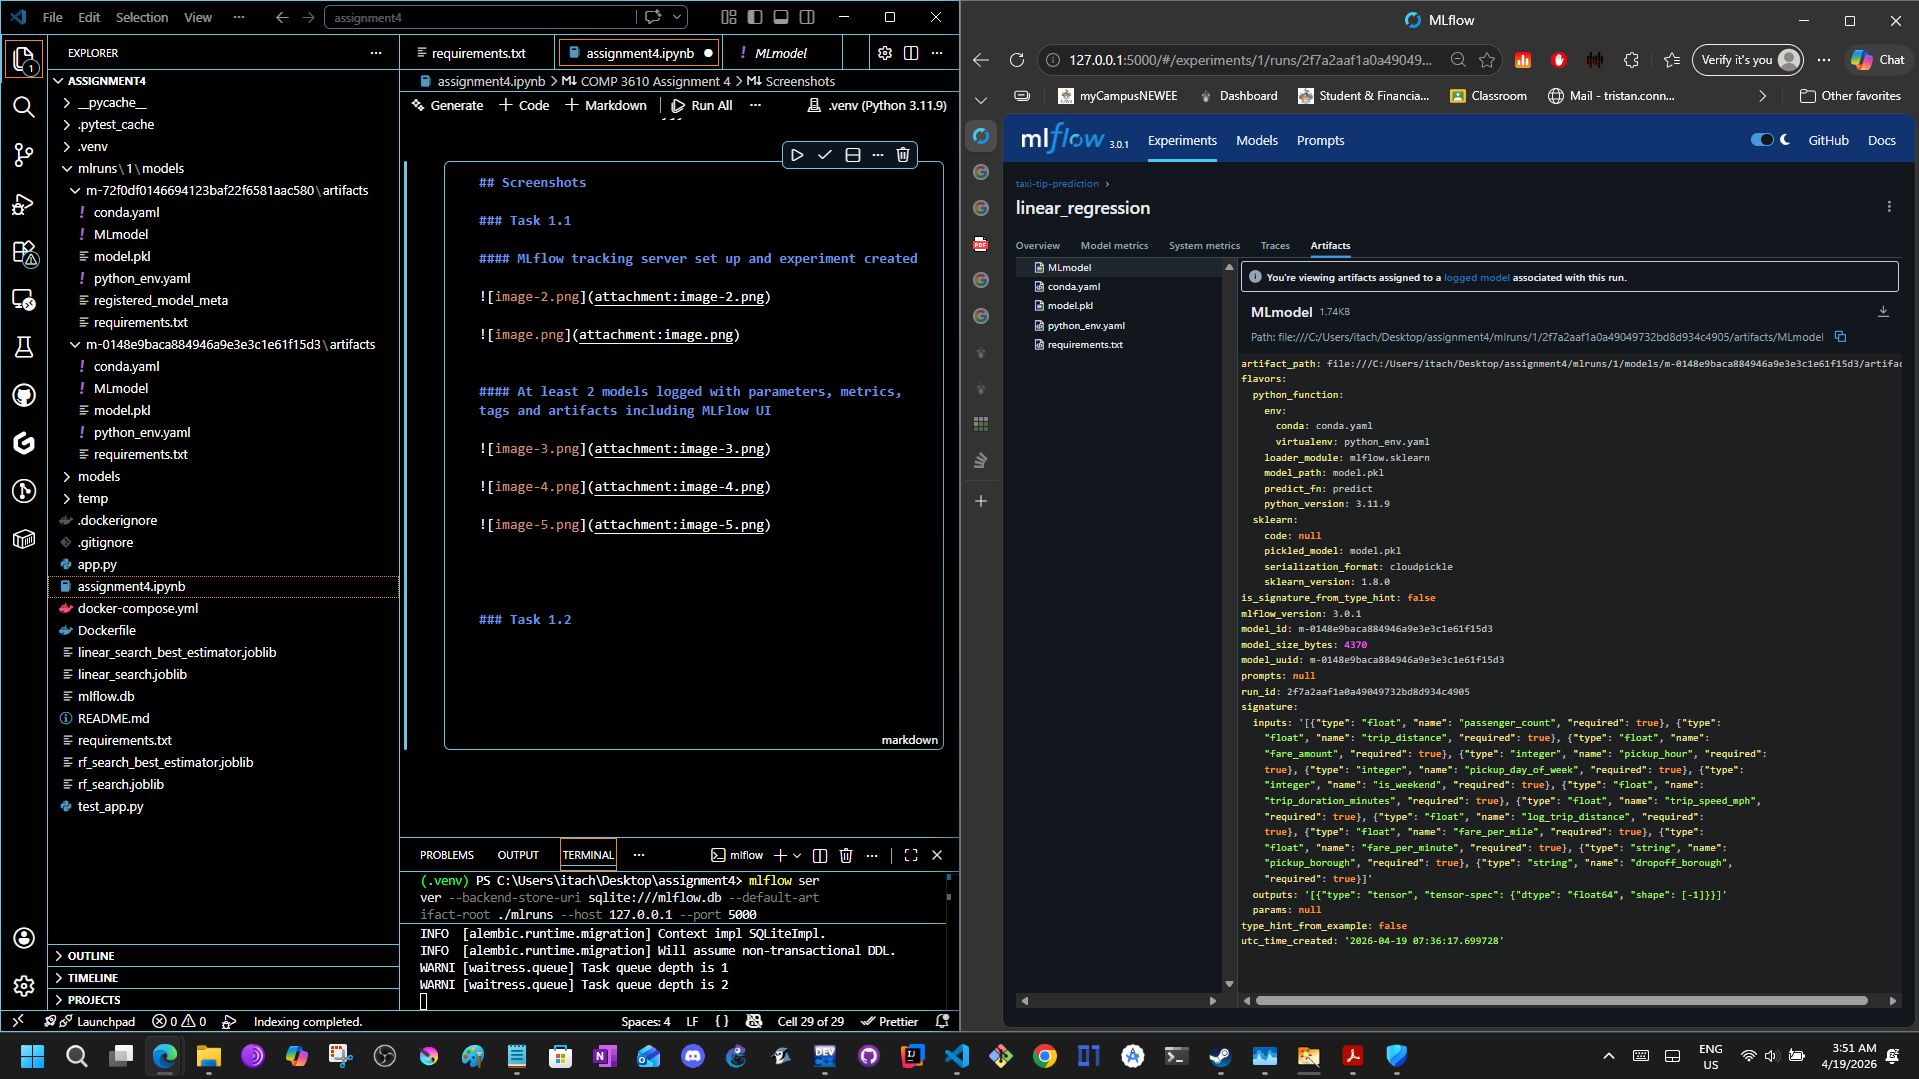

### Side by side comparisons

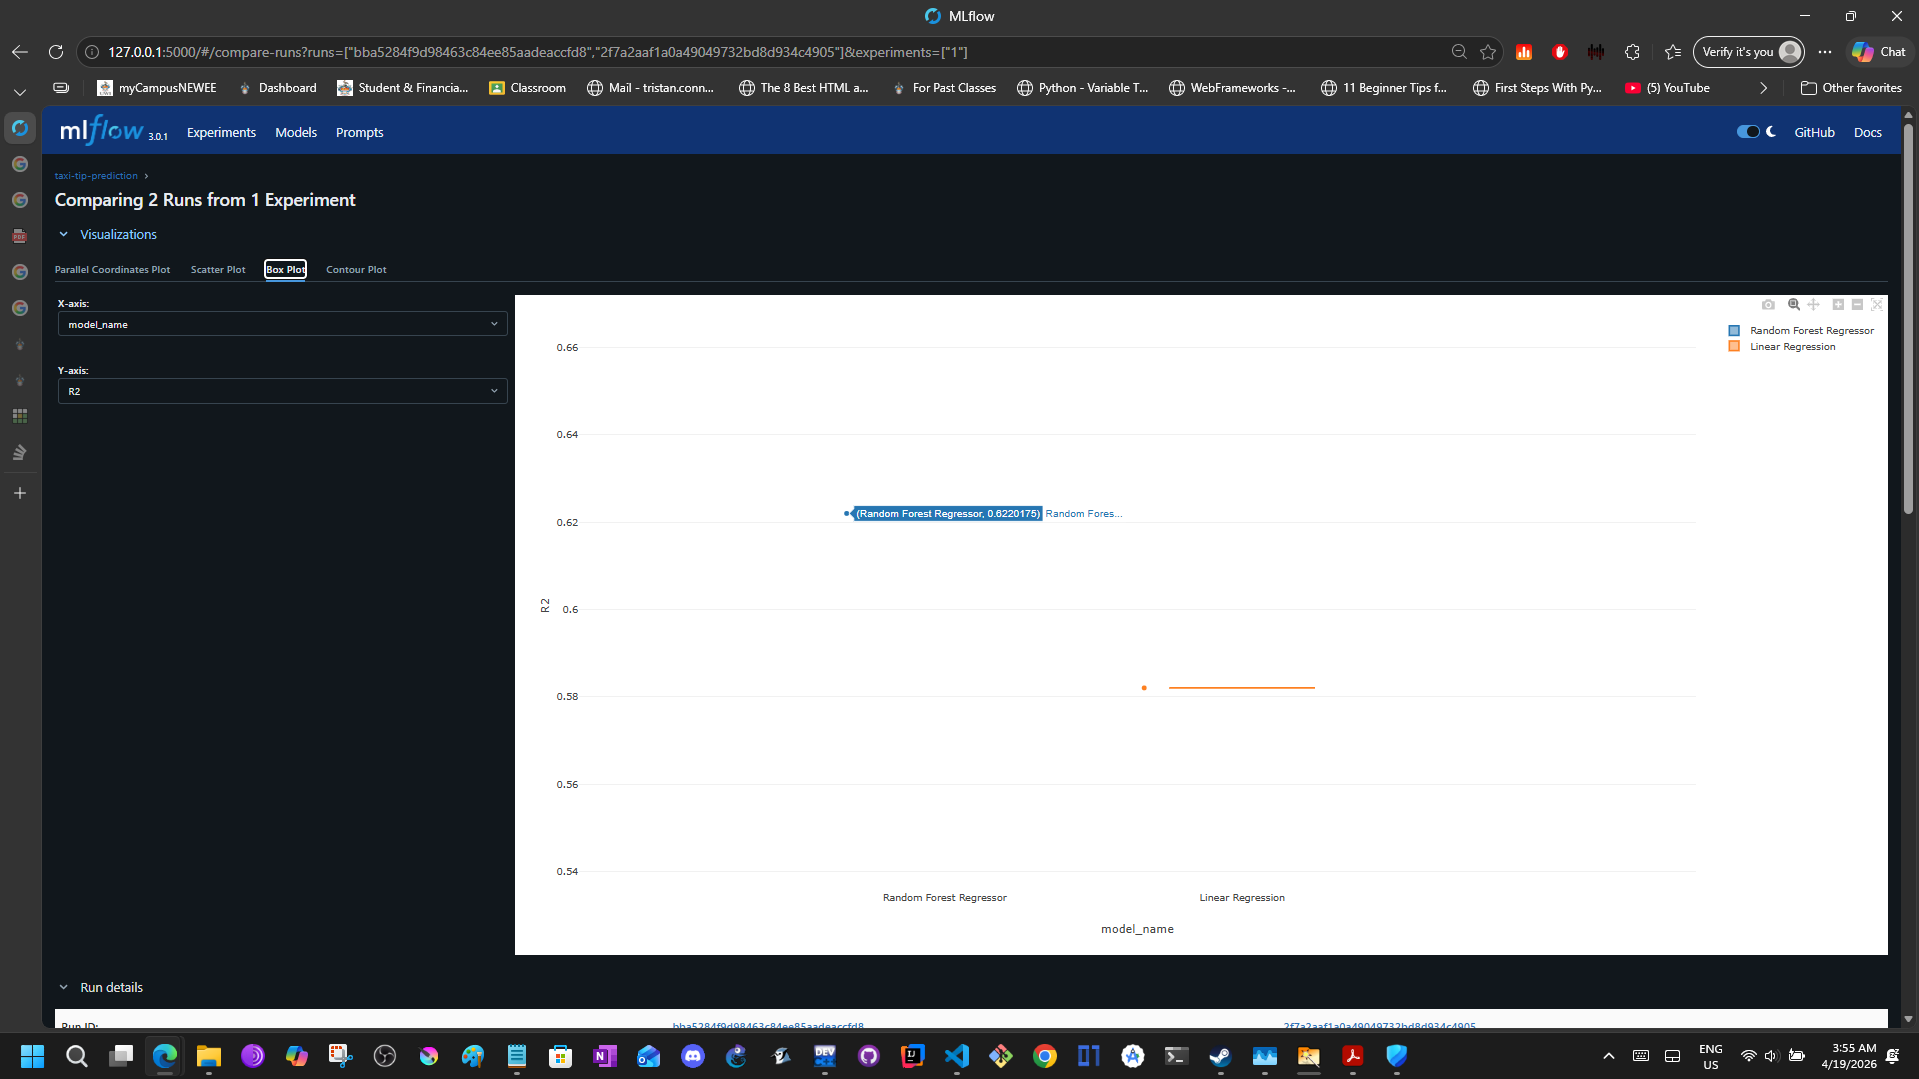

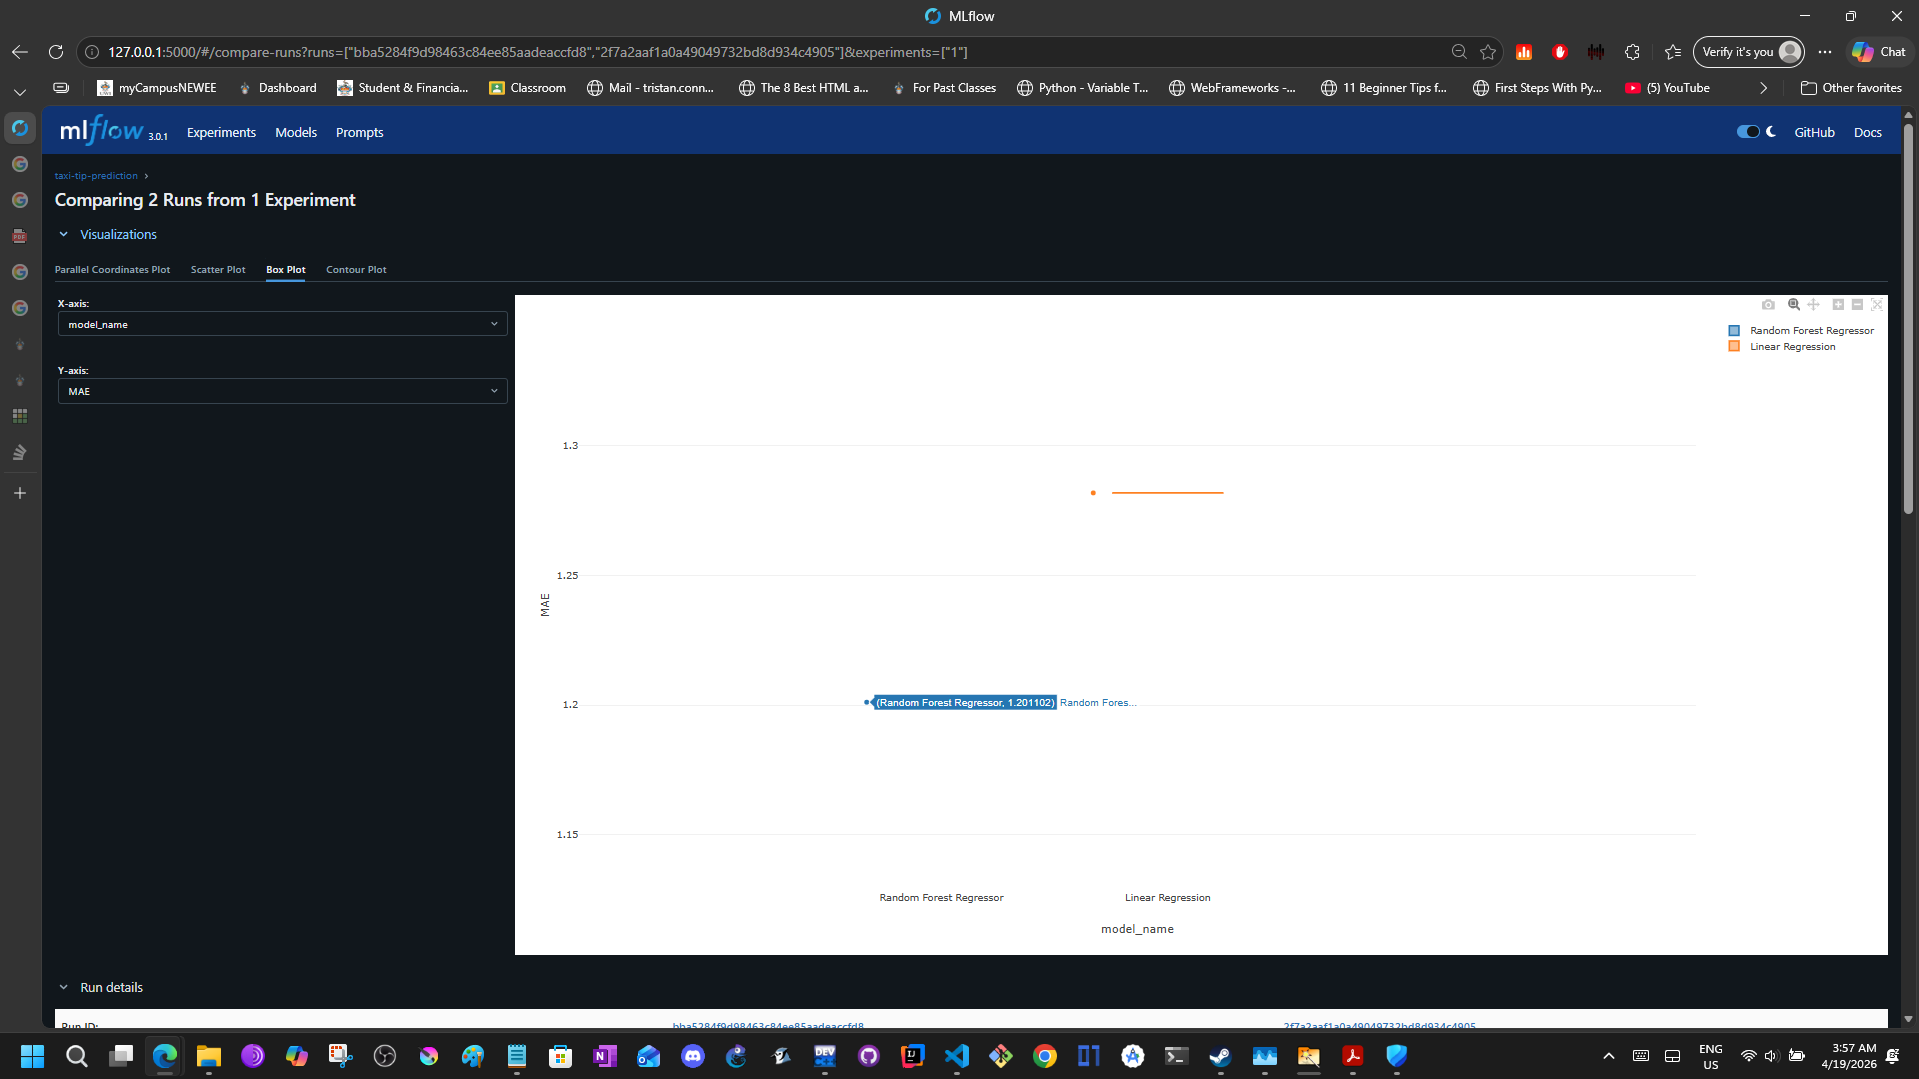

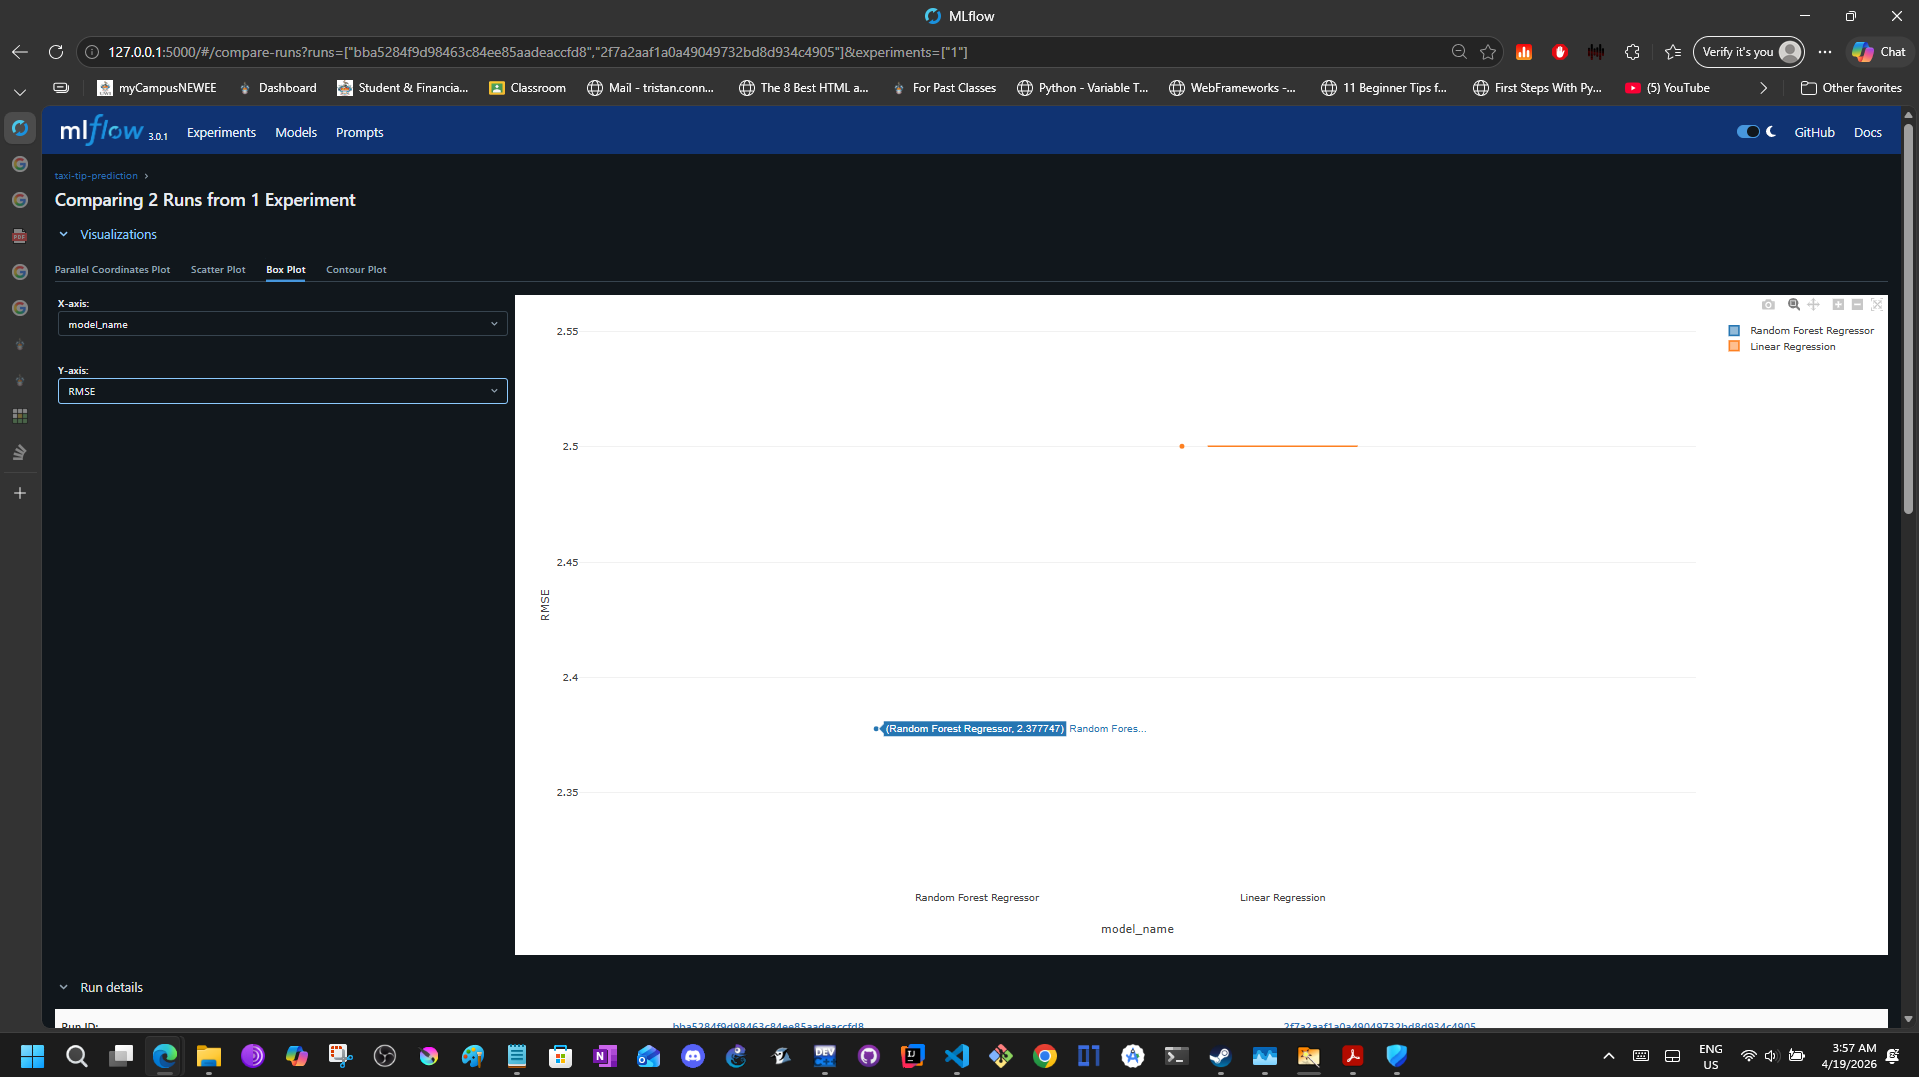

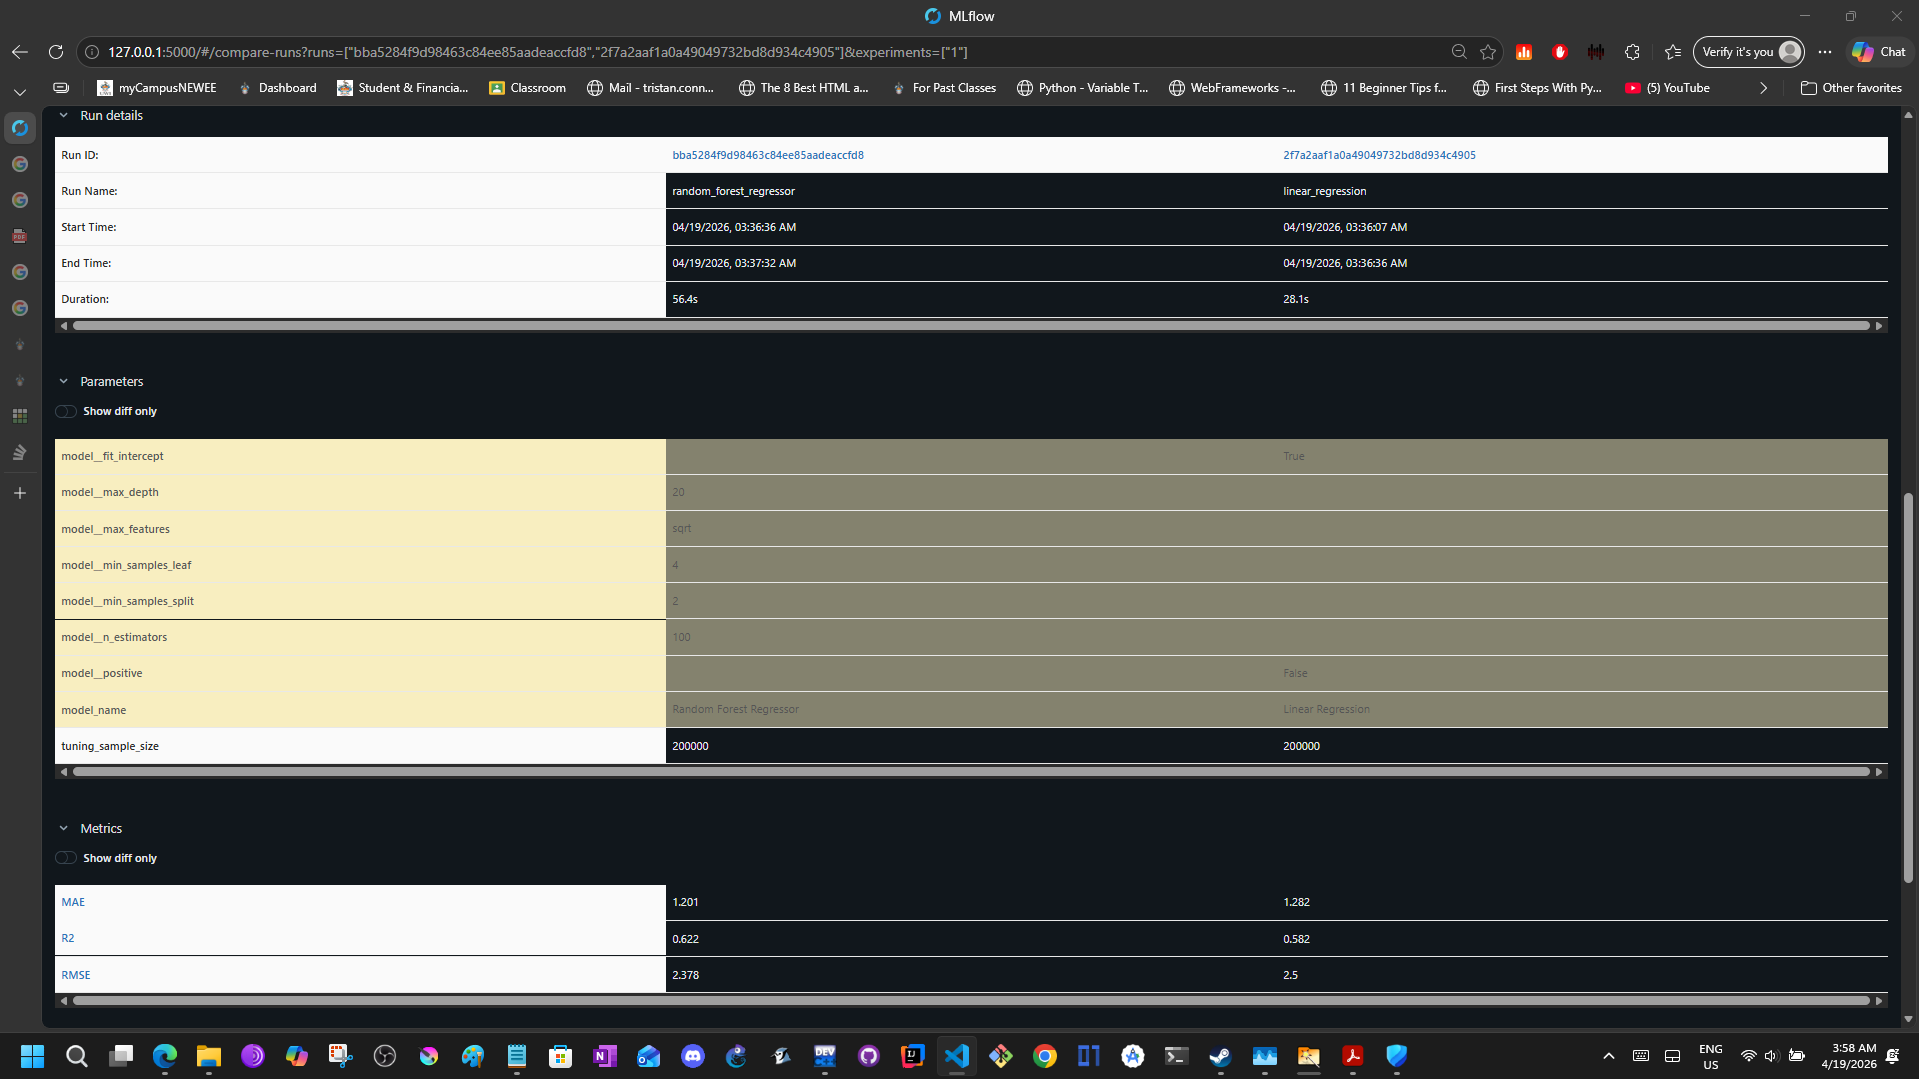

The random forest performed better in every metric except for prediction time which was double that of the linear regression model.

### Model descriptions and registered model with version description

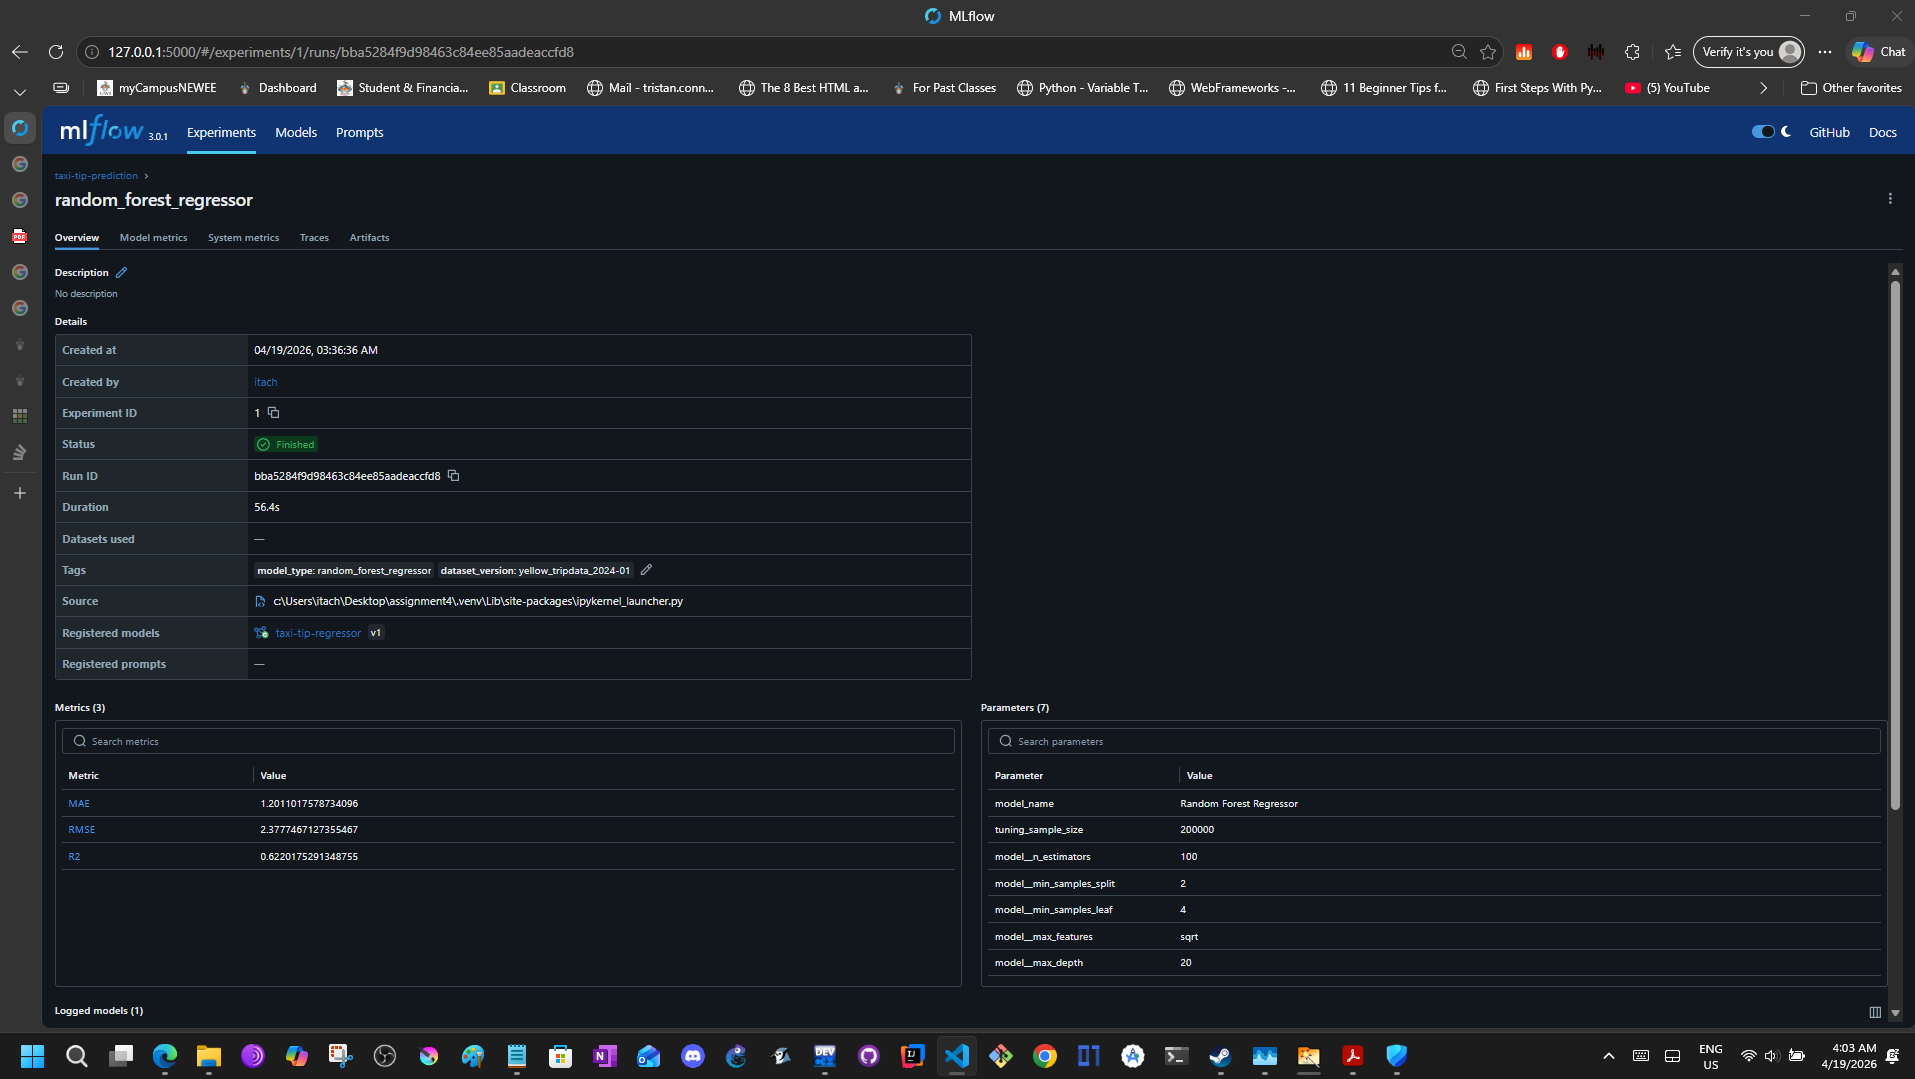

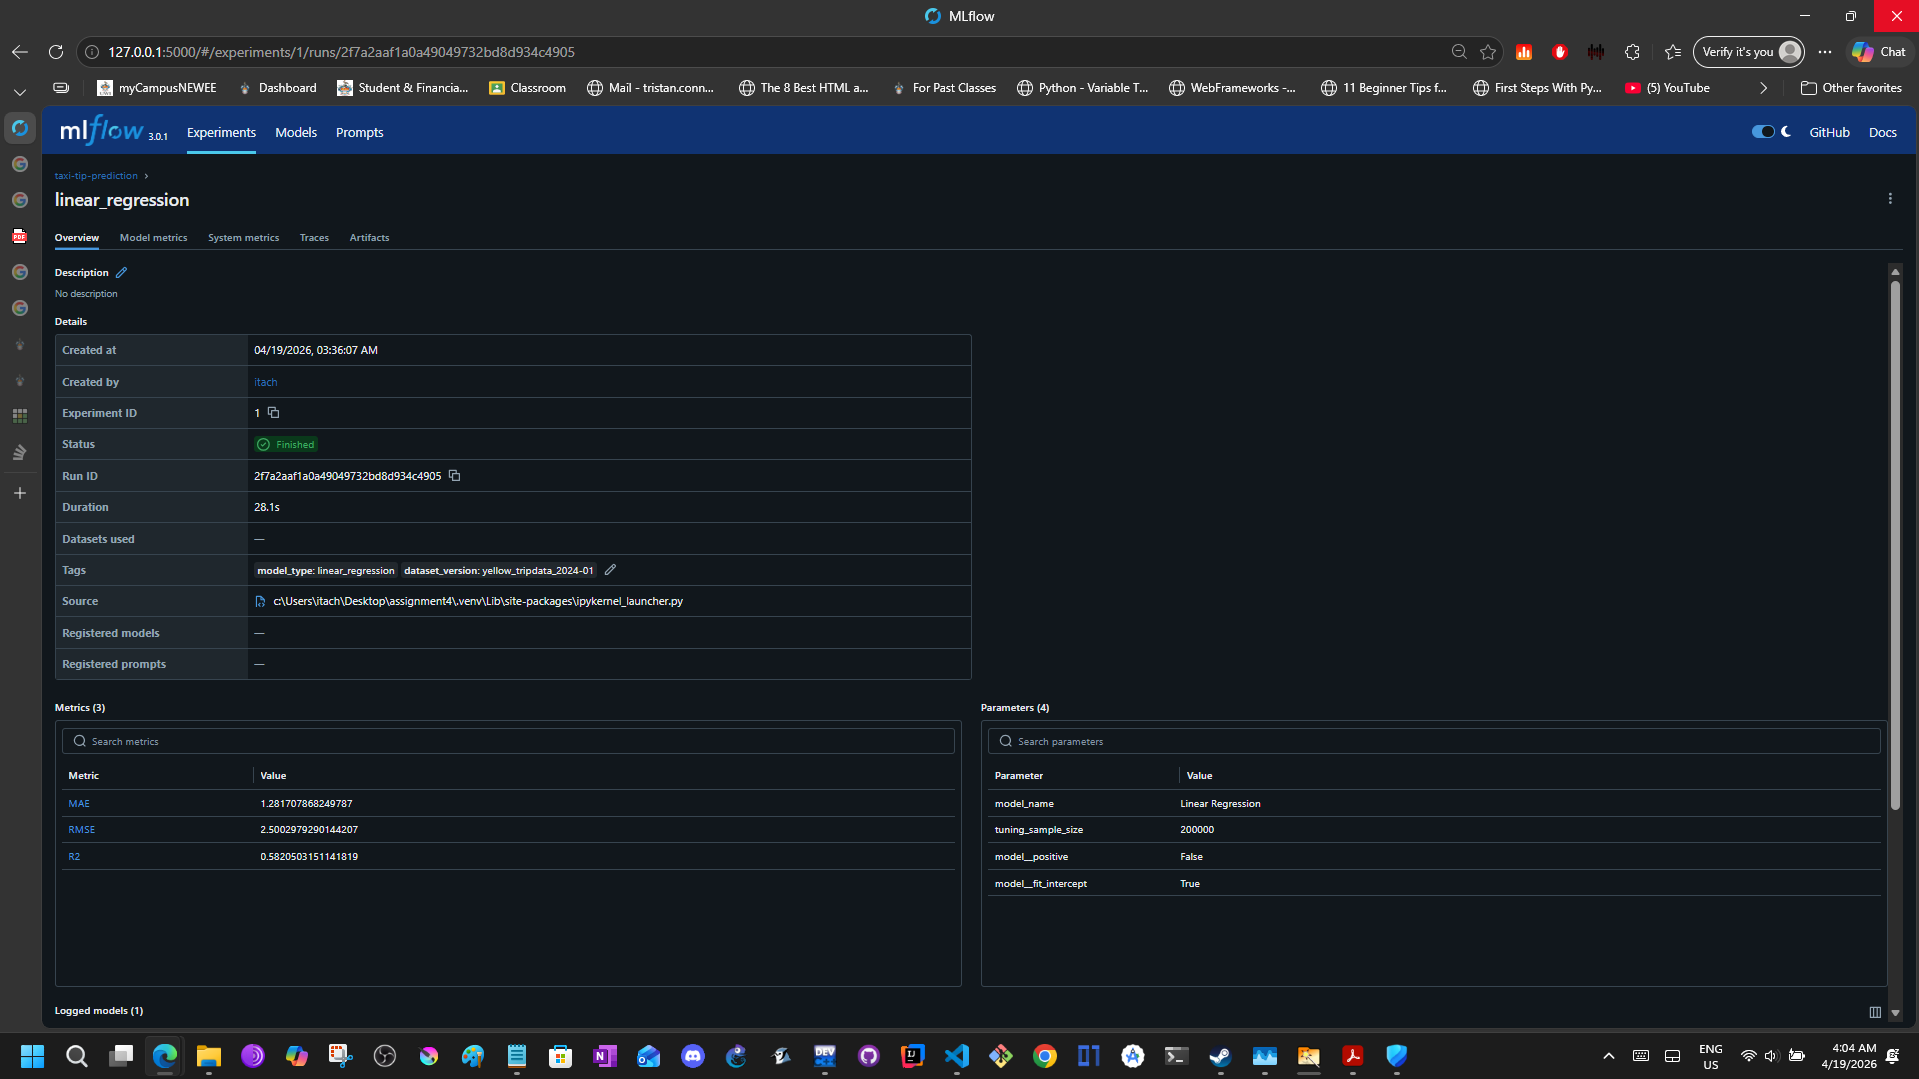

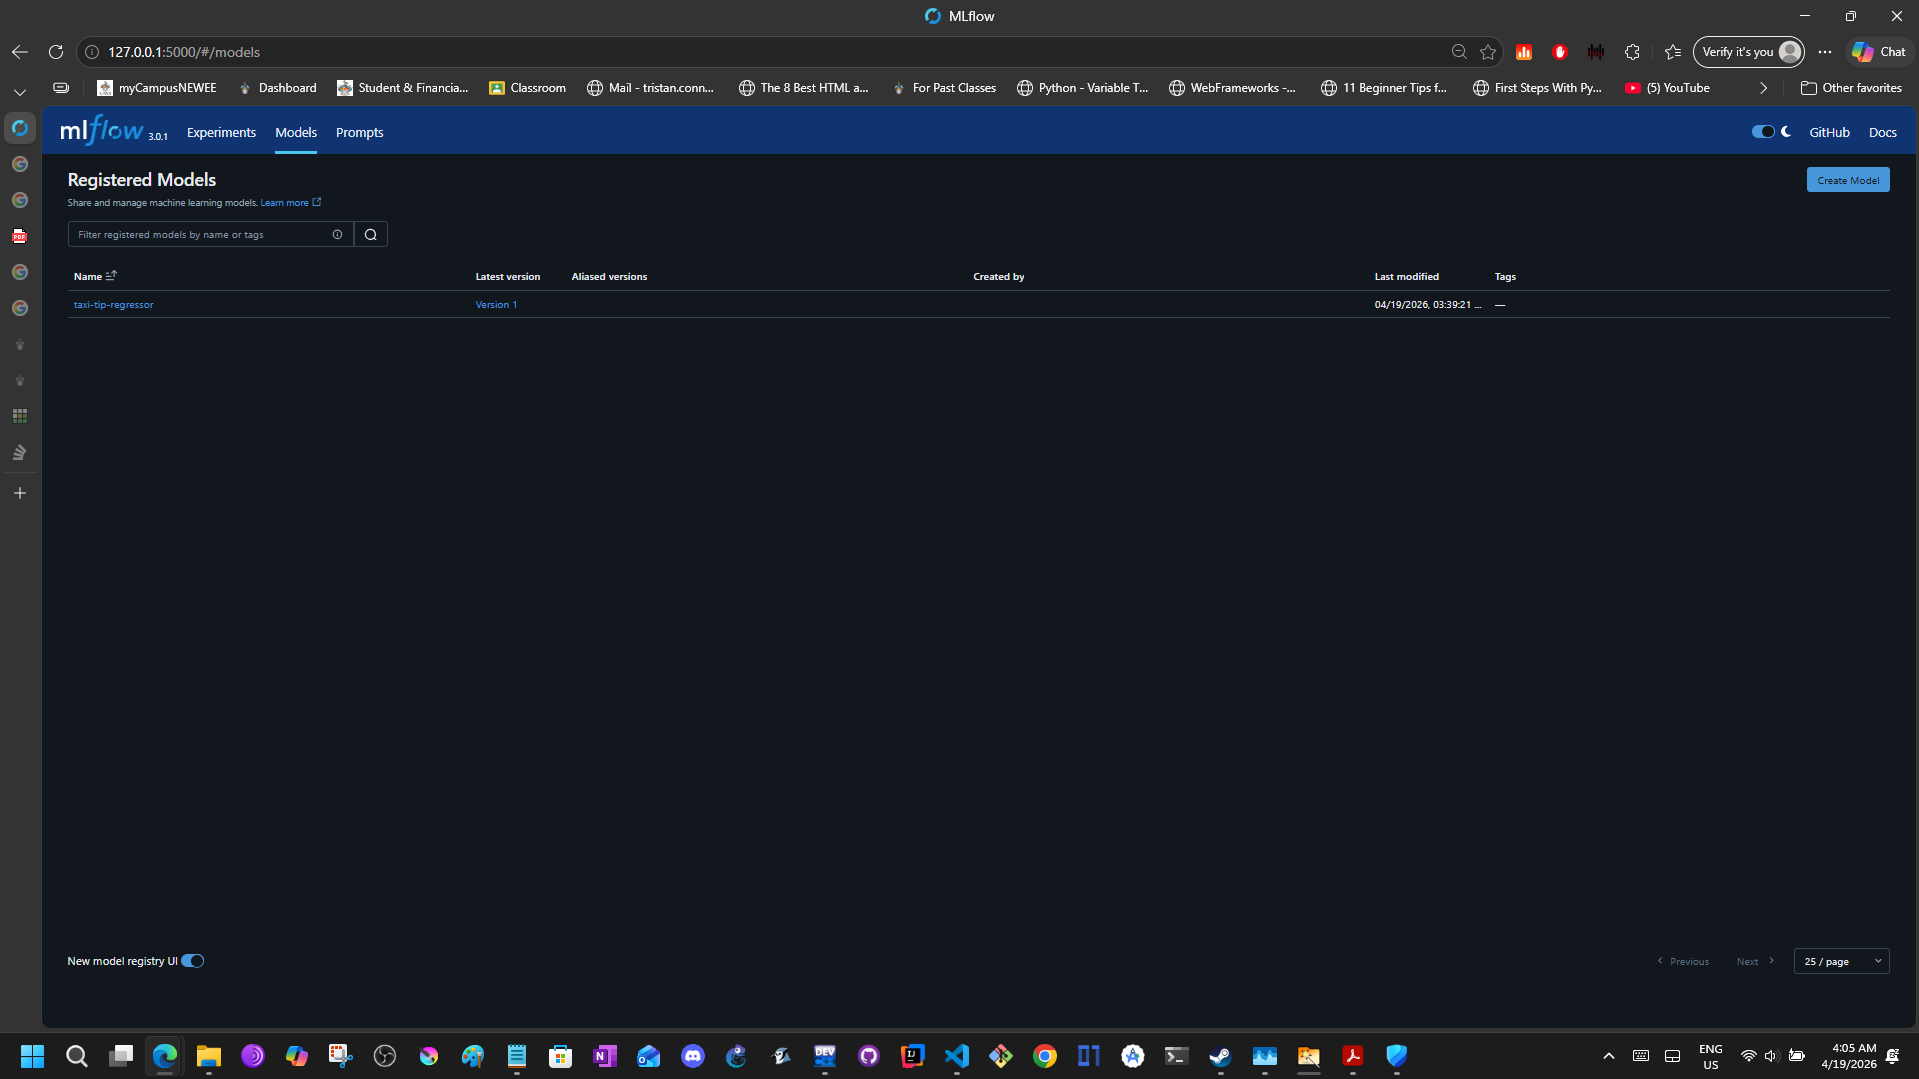

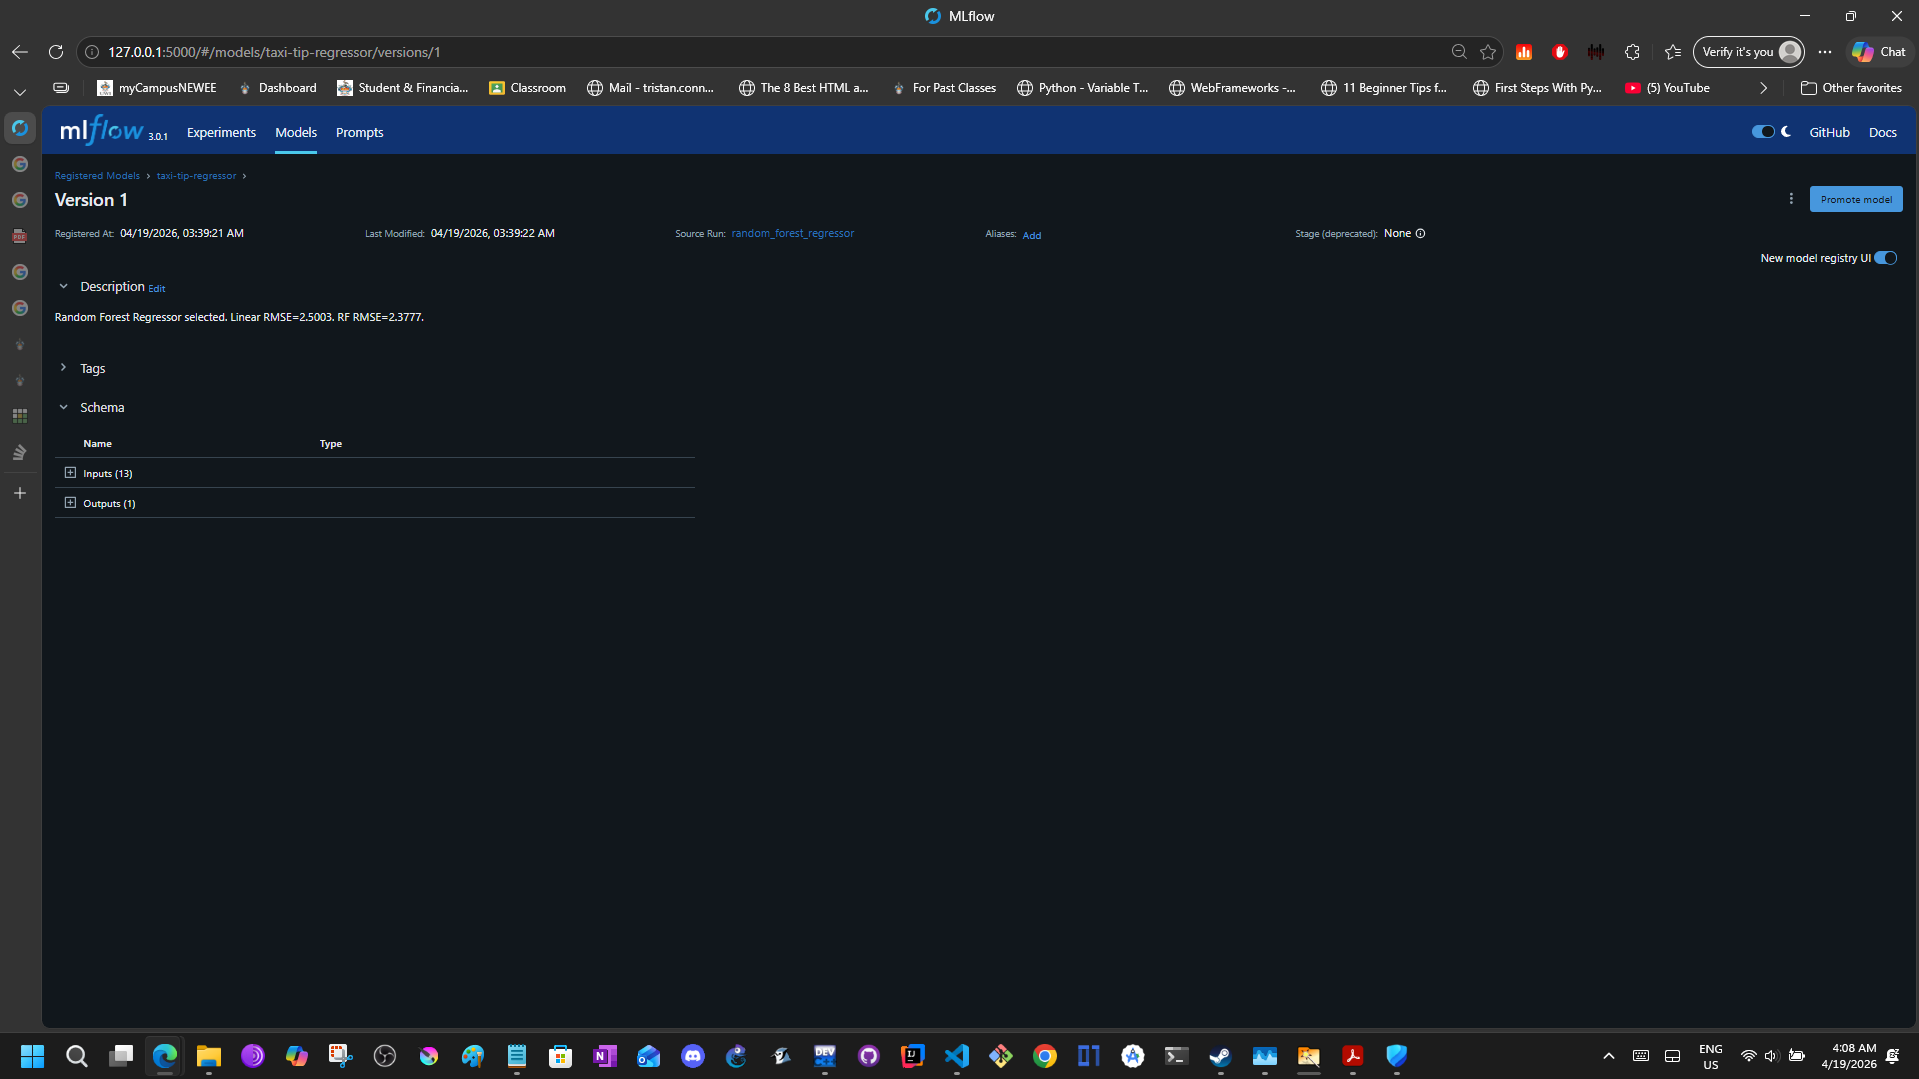

### API Docs

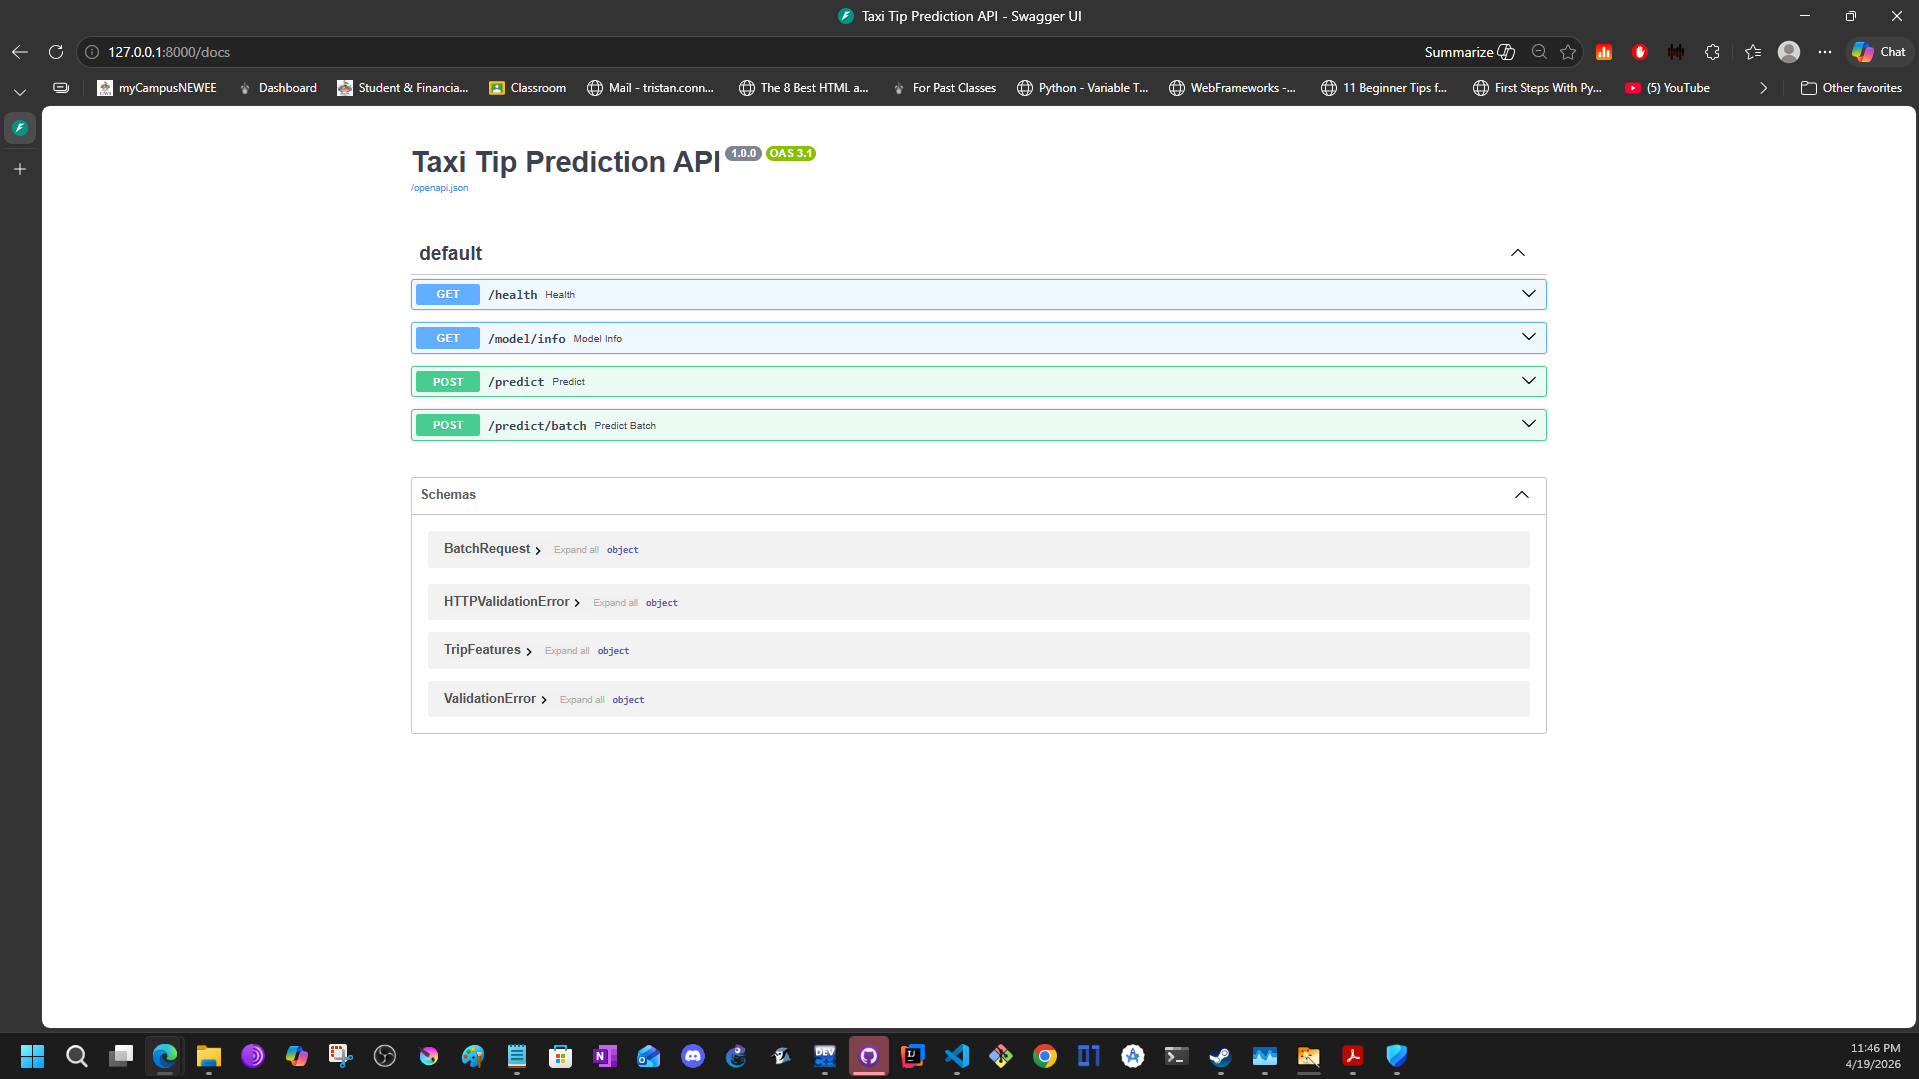


